In [1]:
import os
import json
import warnings

import dfm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 140)

In [2]:
DATA_DIR = "data"

CICIDS_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
def load_cicids_csv(path: str) -> pd.DataFrame:
    """Tek bir CICIDS2017 CSV dosyasini okur ve kolon adlarini temizler."""
    df = pd.read_csv(path, low_memory=False, encoding="cp1252")  # <-- latin1 yerine cp1252
    df.columns = [c.strip() for c in df.columns]
    df["source_file"] = os.path.basename(path)
    return df


def load_all_flows(data_dir: str = DATA_DIR, files=None) -> pd.DataFrame:
    """data/ klasorundeki mevcut tum CICIDS2017 dosyalarini birlestirir."""
    files = files or CICIDS_FILES
    frames = []
    for f in files:
        p = os.path.join(data_dir, f)
        if os.path.exists(p):
            frames.append(load_cicids_csv(p))
        else:
            print(f"[uyari] bulunamadi, atlaniyor: {p}")
    if not frames:
        return None
    return pd.concat(frames, ignore_index=True)


df_raw = load_all_flows()

# Teshis: Web Attack etiketlerinin ham halini gorelim
web_attack_raw = df_raw[df_raw["Label"].str.contains("Web Attack", case=False, na=False)]["Label"].unique()
for lbl in web_attack_raw:
    print(repr(lbl))

if df_raw is not None:
    print("Toplam akis (flow) sayisi:", len(df_raw))
    print(df_raw["Label"].value_counts())
else:
    print("data/ klasorunde dosya bulunamadi -> asagida sentetik ornek ile devam edilecek.")

'Web Attack ï¿½ Brute Force'
'Web Attack ï¿½ XSS'
'Web Attack ï¿½ Sql Injection'
Toplam akis (flow) sayisi: 2830743
Label
BENIGN                          2273097
DoS Hulk                         231073
PortScan                         158930
DDoS                             128027
DoS GoldenEye                     10293
FTP-Patator                        7938
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1966
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64


In [4]:
def prepare_classified_flows(df: pd.DataFrame, label_col: str = "Label", pred_df: pd.DataFrame = None, seed: int = 42) -> pd.DataFrame:
    """
    df        : ham (veya ozellik cikarilmis) akis verisi
    pred_df   : [binary_pred, risk_category, confidence] kolonlarini iceren, df ile ayni index'e sahip
                GERCEK model tahminleri. Kendi Morpheus/siniflandirici ciktinizi buraya verin.
    label_col : pred_df verilmezse demo amacli kullanilacak gercek etiket kolonu (CICIDS2017 'Label')
    """
    df = df.copy()

    if pred_df is not None:
        return df.join(pred_df[["binary_pred", "risk_category", "confidence"]])

    # ---- DEMO MODU: gercek Label'i "model tahmini" gibi kullan (kendi modelinizle degistirin) ----
    rng = np.random.default_rng(seed)
    df["risk_category"] = df[label_col].astype(str).str.strip()
    df["binary_pred"] = np.where(df["risk_category"].str.upper() == "BENIGN", 0, 1)
    df["confidence"] = np.where(
        df["binary_pred"] == 1,
        rng.uniform(0.70, 0.99, size=len(df)),
        rng.uniform(0.85, 0.999, size=len(df)),
    )
    return df

In [5]:
MITRE_MAPPING = {
    "BENIGN": None,

    "DDoS": {
        "tactic": "Impact", "technique_id": "T1498", "technique_name": "Network Denial of Service",
        "severity": "High",
        "precautions": [
            "Upstream DDoS scrubbing / oran sinirlama (rate limiting) etkinlestir",
            "Kenar yonlendiricilerde SYN cookie ac",
            "BGP blackhole / flowspec yonlendirme hazirla",
            "Bant genisligi yedegini artir, otomatik olcekleme (autoscale) yapilandir",
        ],
    },
    "DoS Hulk": {
        "tactic": "Impact", "technique_id": "T1499.002", "technique_name": "Endpoint DoS: Service Exhaustion Flood",
        "severity": "High",
        "precautions": [
            "WAF uzerinde istek hiz siniri (rate limit) uygula",
            "Web sunucu baglanti zaman asimini (timeout) sikilastir",
            "Yuk dengeleyici (load balancer) otomatik olceklendirme ekle",
        ],
    },
    "DoS GoldenEye": {
        "tactic": "Impact", "technique_id": "T1499.002", "technique_name": "Endpoint DoS: Service Exhaustion Flood",
        "severity": "High",
        "precautions": [
            "Web sunucu baglanti havuzunu sikilastir",
            "IDS/IPS uzerinde GoldenEye imzasini etkinlestir",
            "WAF rate-limiting kurallari uygula",
        ],
    },
    "DoS slowloris": {
        "tactic": "Impact", "technique_id": "T1499.004", "technique_name": "Endpoint DoS: Application Exhaustion Flood",
        "severity": "Medium",
        "precautions": [
            "mod_reqtimeout vb. yavas baglanti korumasi ekle",
            "Es zamanli baglanti sinirini dusur",
            "Ters proxy (nginx) arkasina al",
        ],
    },
    "DoS Slowhttptest": {
        "tactic": "Impact", "technique_id": "T1499.004", "technique_name": "Endpoint DoS: Application Exhaustion Flood",
        "severity": "Medium",
        "precautions": [
            "Istek basi zaman asimi suresini kisalt",
            "Baglanti/istemci basina hiz siniri koy",
            "Ters proxy tamponlama (buffering) etkinlestir",
        ],
    },
    "PortScan": {
        "tactic": "Discovery", "technique_id": "T1046", "technique_name": "Network Service Discovery",
        "severity": "Medium",
        "precautions": [
            "Kullanilmayan portlari kapat / guvenlik duvari ile engelle",
            "IDS/IPS tarama tespit imzalarini etkinlestir",
            "Ag segmentasyonu (VLAN/ACL) uygula",
            "Honeypot / aldatma servisi konumlandir",
        ],
    },
    "Bot": {
        "tactic": "Command and Control", "technique_id": "T1071", "technique_name": "Application Layer Protocol (C2)",
        "severity": "High",
        "precautions": [
            "Etkilenen host'u aginan izole et",
            "Bilinen C2 IP/domainlerini engelle",
            "EDR ile kotu amacli yazilim taramasi yap",
            "DNS sinkhole uygula, cikis (egress) trafik filtrelemesi yap",
        ],
    },
    "Web Attack - Brute Force": {   # eskiden "Web Attack – Brute Force"
        "tactic": "Credential Access", "technique_id": "T1110.001", "technique_name": "Brute Force: Password Guessing",
        "severity": "High",
        "precautions": [
            "N basarisiz denemeden sonra hesap kilitleme uygula",
            "Tum girislerde MFA zorunlu kil",
            "WAF ile login endpoint'e hiz siniri koy",
            "Anormal cografi konum / IP engelleme (geo-IP) uygula",
        ],
    },
    "Web Attack - XSS": {   # eskiden "Web Attack – XSS"
        "tactic": "Execution", "technique_id": "T1059.007", "technique_name": "Command and Scripting Interpreter: JavaScript",
        "severity": "Medium",
        "precautions": [
            "Girdi temizleme (sanitization) ve cikti kodlama (encoding) uygula",
            "Content-Security-Policy (CSP) basligi ekle",
            "WAF XSS kural setini etkinlestir",
            "Web uygulama cercevesini guncelle/yama uygula",
        ],
    },
    "Web Attack - Sql Injection": {   # eskiden "Web Attack – Sql Injection"
        "tactic": "Initial Access", "technique_id": "T1190", "technique_name": "Exploit Public-Facing Application",
        "severity": "Critical",
        "precautions": [
            "Parametreli sorgular / ORM kullan",
            "WAF SQL Injection kural setini etkinlestir",
            "Veritabani hesaplarini en az yetki (least privilege) ile sinirla",
            "CMS/ORM yamalarini derhal uygula",
        ],
    },
    "Infiltration": {
        "tactic": "Initial Access / Lateral Movement", "technique_id": "T1190 / T1210",
        "technique_name": "Exploit Public-Facing App + Exploitation of Remote Services",
        "severity": "Critical",
        "precautions": [
            "Bilinen CVE'ler icin acil yama uygula",
            "Ag segmentasyonu ile yanal hareketi (lateral movement) sinirla",
            "EDR dagit; SMB/RDP anomalilerini izle",
            "Etkilenen host'u derhal izole et",
        ],
    },
    "FTP-Patator": {
        "tactic": "Credential Access", "technique_id": "T1110.001", "technique_name": "Brute Force: Password Guessing (FTP)",
        "severity": "High",
        "precautions": [
            "Anonim FTP erisimini kapat",
            "Guclu parola / MFA zorunlu kil",
            "IP izin listesi (allow-list) uygula",
            "fail2ban benzeri engelleme kur, SFTP/FTPS'e gecis yap",
        ],
    },
    "SSH-Patator": {
        "tactic": "Credential Access", "technique_id": "T1110.001", "technique_name": "Brute Force: Password Guessing (SSH)",
        "severity": "High",
        "precautions": [
            "Parola ile kimlik dogrulamayi kapat, sadece anahtar (key) tabanli erisim",
            "fail2ban / IP engelleme uygula",
            "Varsayilan SSH portunu degistir",
            "Kaynak IP kisitla, MFA ekle",
        ],
    },
    "Heartbleed": {
        "tactic": "Initial Access", "technique_id": "T1190", "technique_name": "Exploit Public-Facing Application (CVE-2014-0160)",
        "severity": "Critical",
        "precautions": [
            "OpenSSL'i derhal yama",
            "Sertifika/anahtarlari iptal edip yeniden olustur",
            "Tum sirlari (secrets/tokens) rotate et",
            "Zayif/eski TLS surumlerini devre disi birak",
        ],
    },
}

SEVERITY_WEIGHT = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}

mapping_overview = pd.DataFrame([
    {"risk_category": k, **v} for k, v in MITRE_MAPPING.items() if v is not None
])[["risk_category", "tactic", "technique_id", "technique_name", "severity"]]

mapping_overview

,risk_category,tactic,technique_id,technique_name,severity
0,DDoS,Impact,T1498,Network Denial of Service,High
1,DoS Hulk,Impact,T1499.002,Endpoint DoS: Service Exhaustion Flood,High
2,DoS GoldenEye,Impact,T1499.002,Endpoint DoS: Service Exhaustion Flood,High
3,DoS slowloris,Impact,T1499.004,Endpoint DoS: Application Exhaustion Flood,Medium
4,DoS Slowhttptest,Impact,T1499.004,Endpoint DoS: Application Exhaustion Flood,Medium
5,PortScan,Discovery,T1046,Network Service Discovery,Medium
6,Bot,Command and Control,T1071,Application Layer Protocol (C2),High
7,Web Attack - Brute Force,Credential Access,T1110.001,Brute Force: Password Guessing,High
8,Web Attack - XSS,Execution,T1059.007,Command and Scripting Interpreter: JavaScript,Medium
9,Web Attack - Sql Injection,Initial Access,T1190,Exploit Public-Facing Application,Critical


In [6]:
import re

import re

def normalize_label(lbl) -> str:
    """
    Encoding-bagimsiz normalizasyon. Web Attack etiketlerinde ayirici karakter
    ne olursa olsun (en-dash, latin1/cp1252 hatali byte, UTF-8 replacement
    karakteri, mojibake, duz tire, vb.), sadece 'Web Attack' + anahtar kelime
    (Brute Force / XSS / Sql Injection) substring eslesmesine bakarak dogru
    kanonik etikete cevirir. Boylece encoding sorunu tamamen devre disi kalir.
    """
    s = str(lbl).strip()
    s = re.sub(r"\s+", " ", s)

    if s.upper().startswith("WEB ATTACK"):
        low = s.lower()
        if "brute force" in low:
            return "Web Attack - Brute Force"
        if "xss" in low:
            return "Web Attack - XSS"
        if "sql" in low:
            return "Web Attack - Sql Injection"
        return s  # taninmayan bir Web Attack varyanti - oldugu gibi birak

    return s

def map_to_mitre(df, risk_col="risk_category", conf_col="confidence"):
    df = df.copy()
    df[risk_col] = df[risk_col].apply(normalize_label)

    tactic_map = {k: (v["tactic"] if v else None) for k, v in MITRE_MAPPING.items()}
    tech_id_map = {k: (v["technique_id"] if v else None) for k, v in MITRE_MAPPING.items()}
    tech_name_map = {k: (v["technique_name"] if v else None) for k, v in MITRE_MAPPING.items()}
    severity_map = {k: (v["severity"] if v else None) for k, v in MITRE_MAPPING.items()}
    precaution_map = {k: (v["precautions"] if v else None) for k, v in MITRE_MAPPING.items()}

    df["mitre_tactic"] = df[risk_col].map(tactic_map)
    df["mitre_technique_id"] = df[risk_col].map(tech_id_map)
    df["mitre_technique_name"] = df[risk_col].map(tech_name_map)
    df["severity"] = df[risk_col].map(severity_map)
    df["precautions"] = df[risk_col].map(precaution_map)

    df["severity_weight"] = df["severity"].map(SEVERITY_WEIGHT).fillna(0)
    df["risk_score"] = (df[conf_col].fillna(0) * df["severity_weight"]).round(3)
    return df

In [7]:
def generate_precaution_report(enriched_df: pd.DataFrame) -> pd.DataFrame:
    attacks = enriched_df[enriched_df["mitre_technique_id"].notna()].copy()
    if attacks.empty:
        return pd.DataFrame(columns=["mitre_technique_id", "mitre_technique_name", "tactic", "severity",
                                      "flow_count", "avg_confidence", "total_risk_score", "precautions"])

    report = attacks.groupby(["mitre_technique_id", "mitre_technique_name", "mitre_tactic", "severity"]).agg(
        flow_count=("risk_score", "size"),
        avg_confidence=("confidence", "mean"),
        total_risk_score=("risk_score", "sum"),
    ).reset_index().rename(columns={"mitre_tactic": "tactic"})

    prec_map = attacks.drop_duplicates("mitre_technique_id").set_index("mitre_technique_id")["precautions"].to_dict()
    report["precautions"] = report["mitre_technique_id"].map(prec_map)
    report = report.sort_values("total_risk_score", ascending=False).reset_index(drop=True)
    return report


def build_incident_tickets(enriched_df: pd.DataFrame, top_n: int = 10) -> list:
    attacks = enriched_df[enriched_df["mitre_technique_id"].notna()].copy()
    attacks = attacks.sort_values("risk_score", ascending=False).head(top_n)

    tickets = []
    for i, row in attacks.reset_index().iterrows():
        tickets.append({
            "ticket_id": f"INC-{i + 1:04d}",
            "flow_index": int(row["index"]),
            "risk_category": row["risk_category"],
            "mitre_technique_id": row["mitre_technique_id"],
            "mitre_technique_name": row["mitre_technique_name"],
            "tactic": row["mitre_tactic"],
            "severity": row["severity"],
            "confidence": round(float(row["confidence"]), 3),
            "risk_score": float(row["risk_score"]),
            "recommended_precautions": row["precautions"],
        })
    return tickets

In [8]:
def run_mitre_pipeline(df: pd.DataFrame, pred_df: pd.DataFrame = None, label_col: str = "Label", top_n_tickets: int = 10):
    prepared = prepare_classified_flows(df, label_col=label_col, pred_df=pred_df)
    enriched = map_to_mitre(prepared)
    report = generate_precaution_report(enriched)
    tickets = build_incident_tickets(enriched, top_n=top_n_tickets)
    return enriched, report, tickets

In [9]:
demo_path = os.path.join(DATA_DIR, "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

if os.path.exists(demo_path):
    demo_df = load_cicids_csv(demo_path)
else:
    print("[bilgi] Gercek dosya bulunamadi, sentetik ornek ile demo calistiriliyor.")
    rng = np.random.default_rng(7)
    demo_labels = (["BENIGN"] * 60 + ["DDoS"] * 25 + ["PortScan"] * 5 +
                   ["Web Attack – Brute Force"] * 5 + ["Web Attack – Sql Injection"] * 2 +
                   ["Bot"] * 3)
    demo_df = pd.DataFrame({"Label": demo_labels, "Flow Duration": rng.integers(100, 100000, size=len(demo_labels))})

enriched_demo, report_demo, tickets_demo = run_mitre_pipeline(demo_df, top_n_tickets=5)

print("Toplam akis:", len(enriched_demo), " | Saldiri olarak isaretlenen:", int((enriched_demo["binary_pred"] == 1).sum()))
report_demo

Toplam akis: 225745  | Saldiri olarak isaretlenen: 128027


,mitre_technique_id,mitre_technique_name,tactic,severity,flow_count,avg_confidence,total_risk_score,precautions
0,T1498,Network Denial of Service,Impact,High,128027,0.844969,324536.568,"[Upstream DDoS scrubbing / oran sinirlama (rate limiting) etkinlestir, Kenar..."


In [10]:
all_enriched = []

for fname in CICIDS_FILES:
    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        continue
    day_df = load_cicids_csv(fpath)
    enriched_day, _, _ = run_mitre_pipeline(day_df)
    all_enriched.append(enriched_day)

if all_enriched:
    enriched_all = pd.concat(all_enriched, ignore_index=True)
    weekly_report = generate_precaution_report(enriched_all)
    weekly_tickets = build_incident_tickets(enriched_all, top_n=25)
    print("Haftalik toplam akis:", len(enriched_all))
else:
    print("[bilgi] data/ klasorunde dosya bulunamadi; asagidaki hucreler tek-dosya demo uzerinden calisir.")
    enriched_all = enriched_demo
    weekly_report = report_demo
    weekly_tickets = tickets_demo

weekly_report

Haftalik toplam akis: 2830743


,mitre_technique_id,mitre_technique_name,tactic,severity,flow_count,avg_confidence,total_risk_score,precautions
0,T1499.002,Endpoint DoS: Service Exhaustion Flood,Impact,High,241366,0.844936,611816.655,"[WAF uzerinde istek hiz siniri (rate limit) uygula, Web sunucu baglanti zama..."
1,T1498,Network Denial of Service,Impact,High,128027,0.844969,324536.568,"[Upstream DDoS scrubbing / oran sinirlama (rate limiting) etkinlestir, Kenar..."
2,T1046,Network Service Discovery,Discovery,Medium,158930,0.844879,268553.195,"[Kullanilmayan portlari kapat / guvenlik duvari ile engelle, IDS/IPS tarama ..."
3,T1110.001,Brute Force: Password Guessing (FTP),Credential Access,High,7938,0.846265,20152.980,"[Anonim FTP erisimini kapat, Guclu parola / MFA zorunlu kil, IP izin listesi..."
4,T1499.004,Endpoint DoS: Application Exhaustion Flood,Impact,Medium,11295,0.845683,19103.967,"[mod_reqtimeout vb. yavas baglanti korumasi ekle, Es zamanli baglanti siniri..."
5,T1110.001,Brute Force: Password Guessing (SSH),Credential Access,High,5897,0.844749,14944.502,"[Anonim FTP erisimini kapat, Guclu parola / MFA zorunlu kil, IP izin listesi..."
6,T1071,Application Layer Protocol (C2),Command and Control,High,1966,0.845587,4987.295,"[Etkilenen host'u aginan izole et, Bilinen C2 IP/domainlerini engelle, EDR i..."
7,T1110.001,Brute Force: Password Guessing,Credential Access,High,1507,0.845041,3820.455,"[Anonim FTP erisimini kapat, Guclu parola / MFA zorunlu kil, IP izin listesi..."
8,T1059.007,Command and Scripting Interpreter: JavaScript,Execution,Medium,652,0.845858,1102.991,"[Girdi temizleme (sanitization) ve cikti kodlama (encoding) uygula, Content-..."
9,T1190 / T1210,Exploit Public-Facing App + Exploitation of Remote Services,Initial Access / Lateral Movement,Critical,36,0.818364,117.843,"[Bilinen CVE'ler icin acil yama uygula, Ag segmentasyonu ile yanal hareketi ..."


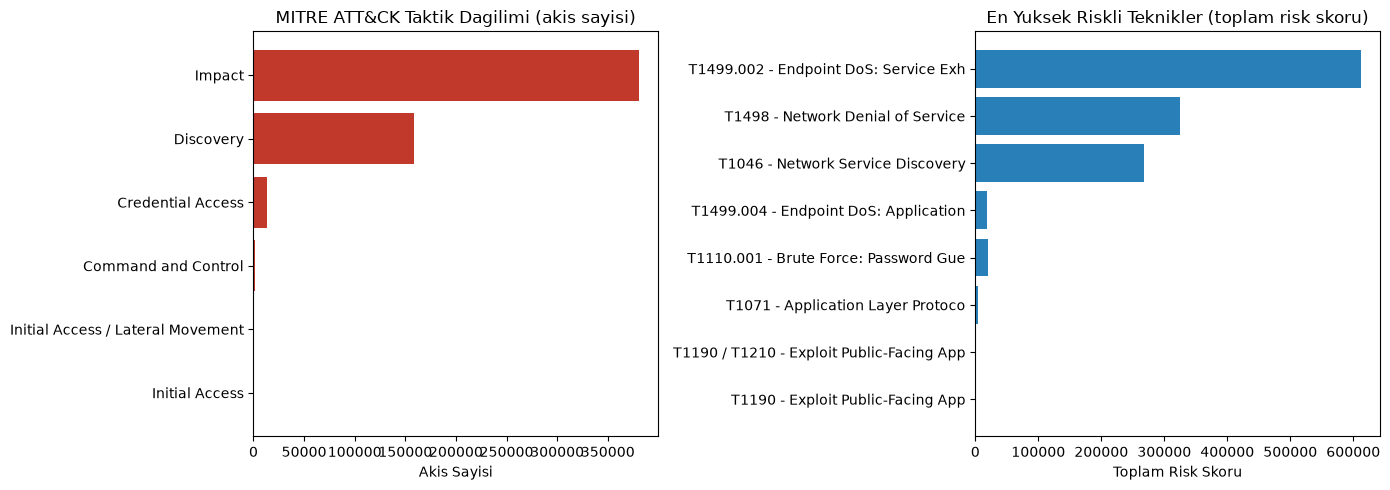

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tactic_counts = enriched_all[enriched_all["mitre_tactic"].notna()]["mitre_tactic"].value_counts()
axes[0].barh(tactic_counts.index[::-1], tactic_counts.values[::-1], color="#c0392b")
axes[0].set_title("MITRE ATT&CK Taktik Dagilimi (akis sayisi)")
axes[0].set_xlabel("Akis Sayisi")

top_tech = weekly_report.head(10).sort_values("total_risk_score")
axes[1].barh(top_tech["mitre_technique_id"] + " - " + top_tech["mitre_technique_name"].str.slice(0, 25),
             top_tech["total_risk_score"], color="#2980b9")
axes[1].set_title("En Yuksek Riskli Teknikler (toplam risk skoru)")
axes[1].set_xlabel("Toplam Risk Skoru")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mitre_dashboard.png"), dpi=150)
plt.show()

In [12]:
enriched_all.drop(columns=["precautions"]).to_csv(os.path.join(OUTPUT_DIR, "enriched_flows.csv"), index=False)
weekly_report.to_csv(os.path.join(OUTPUT_DIR, "mitre_precaution_report.csv"), index=False)

with open(os.path.join(OUTPUT_DIR, "incident_tickets.json"), "w", encoding="utf-8") as f:
    json.dump(weekly_tickets, f, ensure_ascii=False, indent=2)

print("Kaydedildi:")
print(" -", os.path.join(OUTPUT_DIR, "enriched_flows.csv"))
print(" -", os.path.join(OUTPUT_DIR, "mitre_precaution_report.csv"))
print(" -", os.path.join(OUTPUT_DIR, "incident_tickets.json"))
print(" -", os.path.join(OUTPUT_DIR, "mitre_dashboard.png"))

Kaydedildi:
 - outputs/enriched_flows.csv
 - outputs/mitre_precaution_report.csv
 - outputs/incident_tickets.json
 - outputs/mitre_dashboard.png
